# Phase 1: Data Selection and Exploration

## 1. Project Goal
The goal of this project is to apply data mining techniques to Alzheimer’s disease data. For classification, the project aims to classify patients based on the Diagnosis attribute, which indicates whether a patient is diagnosed with Alzheimer’s disease, using demographic, lifestyle, medical, clinical, cognitive, and functional characteristics. For clustering, the project aims to group patients with similar characteristics in order to identify meaningful patterns and similarities within the dataset.

## 2. Dataset Source
The dataset used in this project is the Alzheimer’s Disease Dataset, obtained from Kaggle.

Dataset URL: https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

## 3. Dataset Description
The Alzheimer's Disease Dataset contains information about 2,149 patients and consists of 35 attributes. The attributes include demographic, lifestyle, medical, clinical, cognitive, and functional information. The class attribute is Diagnosis, which indicates whether a patient has Alzheimer's disease.


In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/Wafa-Alobaidi/IT326-Data-Mining-Project/refs/heads/main/Dataset/Raw_dataset.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of attributes:", df.shape[1])

Number of rows: 2149
Number of attributes: 35


In [ ]:
print(df.dtypes)

PatientID                      int64
Age                            int64
Gender                         int64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                        int64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease          int64
Diabetes                       int64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                    int64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints               int64
BehavioralProblems             int64
A

In [ ]:
print("Class attribute: Diagnosis")
print("Class values:", df["Diagnosis"].unique())

Class attribute: Diagnosis
Class values: [0 1]


In [ ]:
print("Number of instances for each class:")
print(df["Diagnosis"].value_counts())

Number of instances for each class:
Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [ ]:
print("Sample of Raw Dataset (First 5 Rows):")
df.head()

Sample of Raw Dataset (First 5 Rows):


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


# Phase 2: Data Preprocessing

## 1. Statistical Summary & Missing Values




In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/Wafa-Alobaidi/IT326-Data-Mining-Project/refs/heads/main/Dataset/Raw_dataset.csv')

print("Shape:", df.shape)
df.info()

Shape: (2149, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   214

In [ ]:
id_cols = ['PatientID', 'DoctorInCharge']

categorical_cols = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking',
    'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression',
    'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
    'Forgetfulness', 'Diagnosis'
]

numeric_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
    'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal',
    'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides',
    'MMSE', 'FunctionalAssessment', 'ADL'
]

# sanity check — run this and confirm it prints an empty set
leftover = set(df.columns) - set(id_cols + categorical_cols + numeric_cols)
print("Unclassified columns:", leftover)

Unclassified columns: set()


In [ ]:
# Numeric summary
print(df[numeric_cols].describe())

# Categorical summary
for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

               Age          BMI  AlcoholConsumption  PhysicalActivity  \
count  2149.000000  2149.000000         2149.000000       2149.000000   
mean     74.908795    27.655697           10.039442          4.920202   
std       8.990221     7.217438            5.757910          2.857191   
min      60.000000    15.008851            0.002003          0.003616   
25%      67.000000    21.611408            5.139810          2.570626   
50%      75.000000    27.823924            9.934412          4.766424   
75%      83.000000    33.869778           15.157931          7.427899   
max      90.000000    39.992767           19.989293          9.987429   

       DietQuality  SleepQuality   SystolicBP  DiastolicBP  CholesterolTotal  \
count  2149.000000   2149.000000  2149.000000  2149.000000       2149.000000   
mean      4.993138      7.051081   134.264774    89.847836        225.197519   
std       2.909055      1.763573    25.949352    17.592496         42.542233   
min       0.009385    

In [ ]:
five_number = df[numeric_cols].describe().loc[['min', '25%', '50%', '75%', 'max']]
print(five_number)

      Age        BMI  AlcoholConsumption  PhysicalActivity  DietQuality  \
min  60.0  15.008851            0.002003          0.003616     0.009385   
25%  67.0  21.611408            5.139810          2.570626     2.458455   
50%  75.0  27.823924            9.934412          4.766424     5.076087   
75%  83.0  33.869778           15.157931          7.427899     7.558625   
max  90.0  39.992767           19.989293          9.987429     9.998346   

     SleepQuality  SystolicBP  DiastolicBP  CholesterolTotal  CholesterolLDL  \
min      4.002629        90.0         60.0        150.093316       50.230707   
25%      5.482997       112.0         74.0        190.252963       87.195798   
50%      7.115646       134.0         91.0        225.086430      123.342593   
75%      8.562521       157.0        105.0        262.031657      161.733733   
max      9.999840       179.0        119.0        299.993352      199.965665   

     CholesterolHDL  CholesterolTriglycerides       MMSE  \
min     

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0])

# If nothing prints, explicitly state it:
if missing.sum() == 0:
    print("No missing values found in the dataset.")

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
No missing values found in the dataset.


### Interpretation

- **Dataset shape:** The dataset contains 2,149 patients and 35 attributes — 18 categorical/binary variables (including the class label `Diagnosis`), 15 numeric/continuous variables, and 2 identifier columns excluded from analysis.

- **Five-number summary insights:** All 15 numeric attributes fall within plausible clinical and lifestyle ranges (e.g., Age 60–90, SystolicBP 90–179, CholesterolTotal 150–300), with no impossible or extreme values in the min/max. Distributions appear roughly uniform across their ranges rather than skewed, which is examined further in the outlier analysis (Section 2).

- **Missing values:** No missing values were found in any of the 35 columns, confirmed by both the missing-value check and the non-null counts in `df.info()`. This matches published analyses of the same Kaggle dataset. No preprocessing is required for missingness specifically.

- **Excluded columns:** `PatientID` was excluded from statistical interpretation as it is only a unique identifier with no analytical meaning. `DoctorInCharge` was excluded/treated separately, as it holds the same (confidential) value for all patients and is not a useful feature.

- **Overall preprocessing recommendation (from this section only):** No missing-value handling is needed. Whether other preprocessing steps (scaling, outlier treatment, encoding) No missing-value handling is needed. Whether other preprocessing steps (scaling, outlier treatment, encoding) are needed is evaluated in the following sections.

## 2. Outlier Detection & Boxplot Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strictly genuine continuous numeric features per team agreement
continuous_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]

# Calculate IQR bounds and outlier counts
outlier_summary = []
for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_summary.append({
        'Feature': col,
        'Min': round(df[col].min(), 2),
        'Q1 (25%)': round(q1, 2),
        'Median (50%)': round(df[col].median(), 2),
        'Q3 (75%)': round(q3, 2),
        'Max': round(df[col].max(), 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round((len(outliers) / len(df)) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_summary)
print("=== Outlier Detection via IQR Method ===")
display(outlier_table)

=== Outlier Detection via IQR Method ===


,Feature,Min,Q1 (25%),Median (50%),Q3 (75%),Max,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Age,60.00,67.00,75.00,83.00,90.00,43.00,107.00,0,0.0
1,BMI,15.01,21.61,27.82,33.87,39.99,3.22,52.26,0,0.0
2,AlcoholConsumption,0.00,5.14,9.93,15.16,19.99,-9.89,30.19,0,0.0
3,PhysicalActivity,0.00,2.57,4.77,7.43,9.99,-4.72,14.71,0,0.0
4,DietQuality,0.01,2.46,5.08,7.56,10.00,-5.19,15.21,0,0.0
5,SleepQuality,4.00,5.48,7.12,8.56,10.00,0.86,13.18,0,0.0
6,SystolicBP,90.00,112.00,134.00,157.00,179.00,44.50,224.50,0,0.0
7,DiastolicBP,60.00,74.00,91.00,105.00,119.00,27.50,151.50,0,0.0
8,CholesterolTotal,150.09,190.25,225.09,262.03,299.99,82.58,369.70,0,0.0
9,CholesterolLDL,50.23,87.20,123.34,161.73,199.97,-24.61,273.54,0,0.0


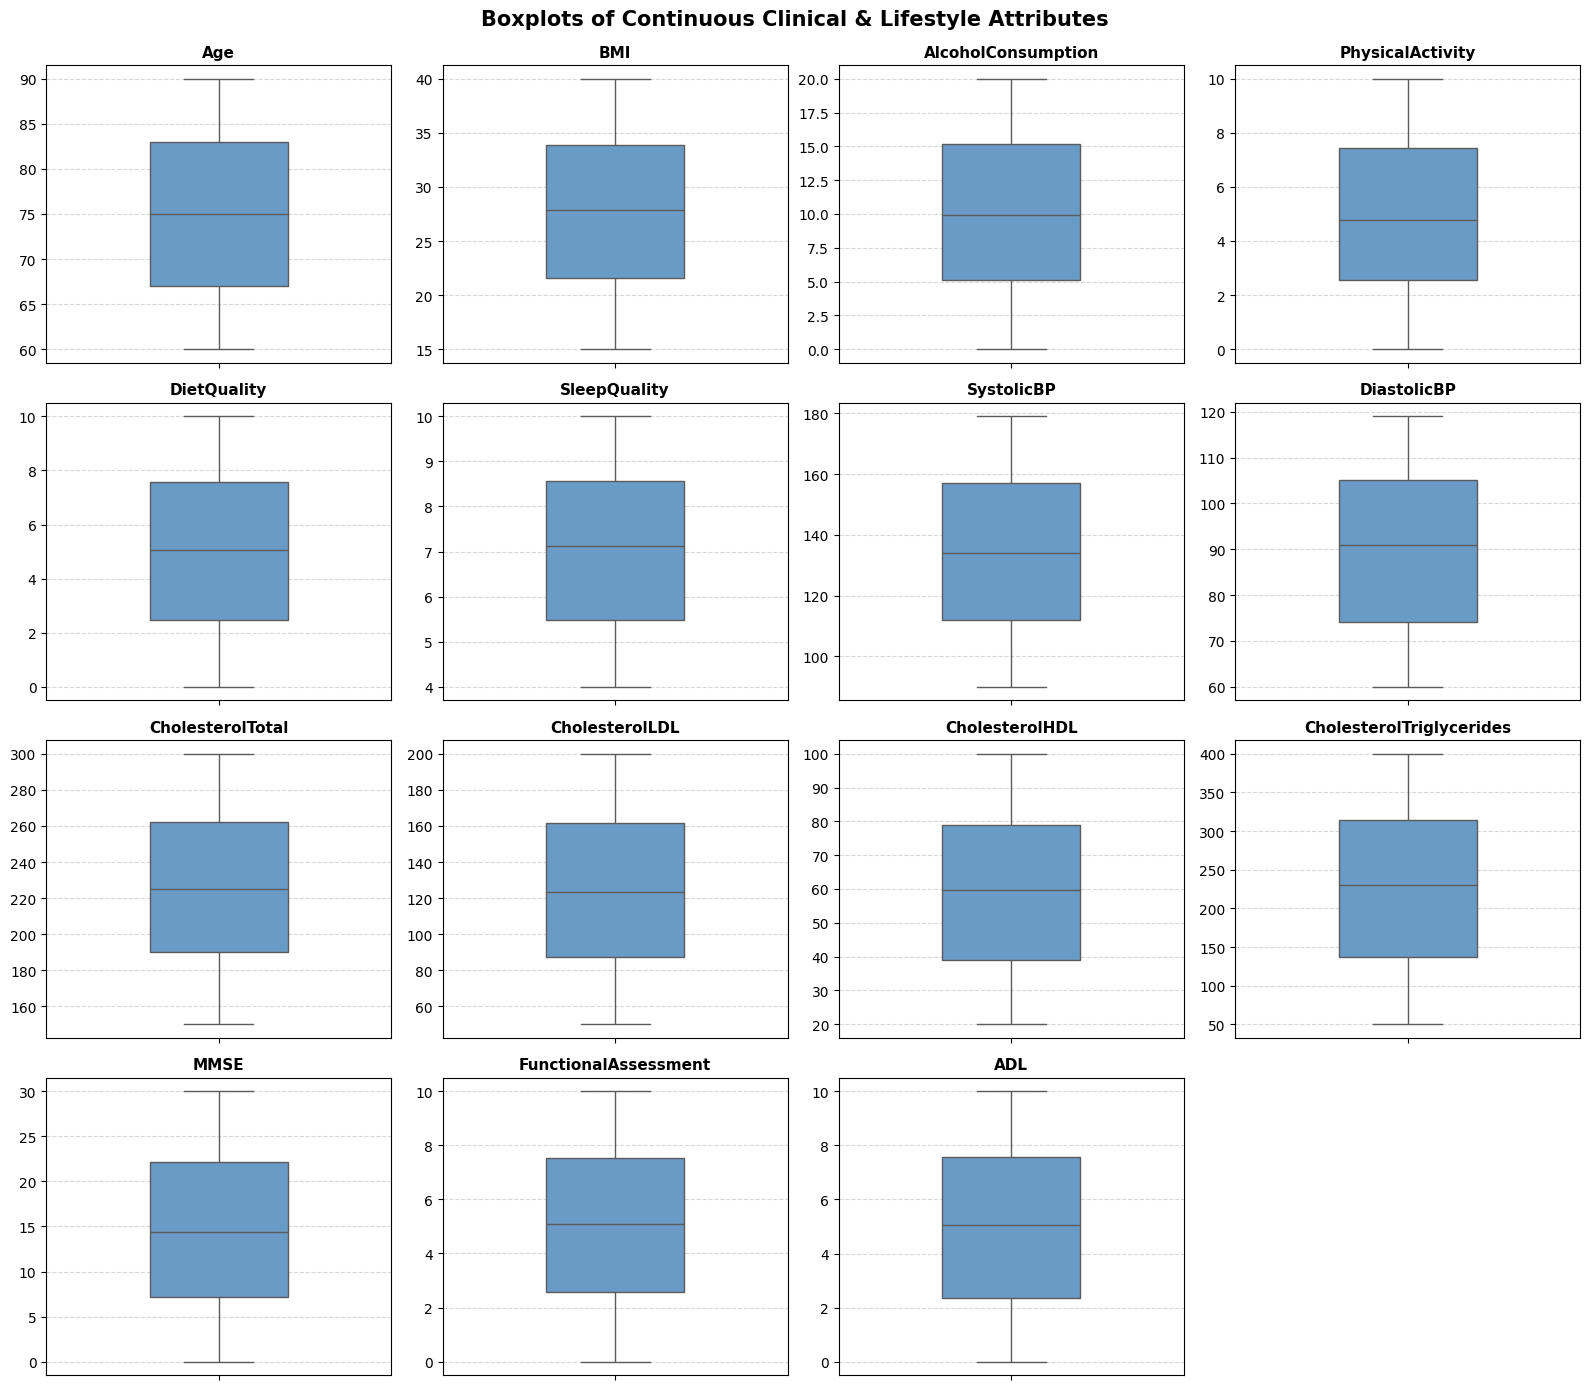

In [ ]:
# Plotting boxplots for all continuous features
plt.figure(figsize=(16, 14))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='#5B9BD5', fliersize=4, width=0.4)
    plt.title(f'{col}', fontsize=11, fontweight='bold')
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Boxplots of Continuous Clinical & Lifestyle Attributes", fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

### Interpretation

* **Scope of analysis:** Outlier detection and boxplot visualization were performed exclusively on the 15 continuous numeric variables (Age, BMI, AlcoholConsumption, PhysicalActivity, DietQuality, SleepQuality, SystolicBP, DiastolicBP, CholesterolTotal, CholesterolLDL, CholesterolHDL, CholesterolTriglycerides, MMSE, FunctionalAssessment, and ADL), excluding all 18 categorical/binary variables as well as PatientID and DoctorInCharge.

* **Boxplot visual observations:** The boxplots show balanced and symmetric distributions across the 15 continuous attributes. Medians are positioned near the center of the interquartile boxes, and the whiskers span the entire observed range from minimum to maximum without isolated points extending beyond the bounds (outliers).

* **Outlier detection results:** Using the standard $1.5 \times IQR$ rule ($[\text{Lower Bound} = Q_1 - 1.5 \times IQR, \text{Upper Bound} = Q_3 + 1.5 \times IQR]$), zero outliers (0 instances, 0.0%) were detected in any of the 15 attributes. All minimum and maximum values fall strictly within their respective calculated lower and upper thresholds.

* **Overall preprocessing recommendation (from this section):** No outlier treatment (such as trimming, removal, or Winsorization/capping) is required or justified, as modifying valid clinical records would distort natural variations.

## 3. Distributions & Class Analysis

### 3.1 Numerical Attribute Distributions

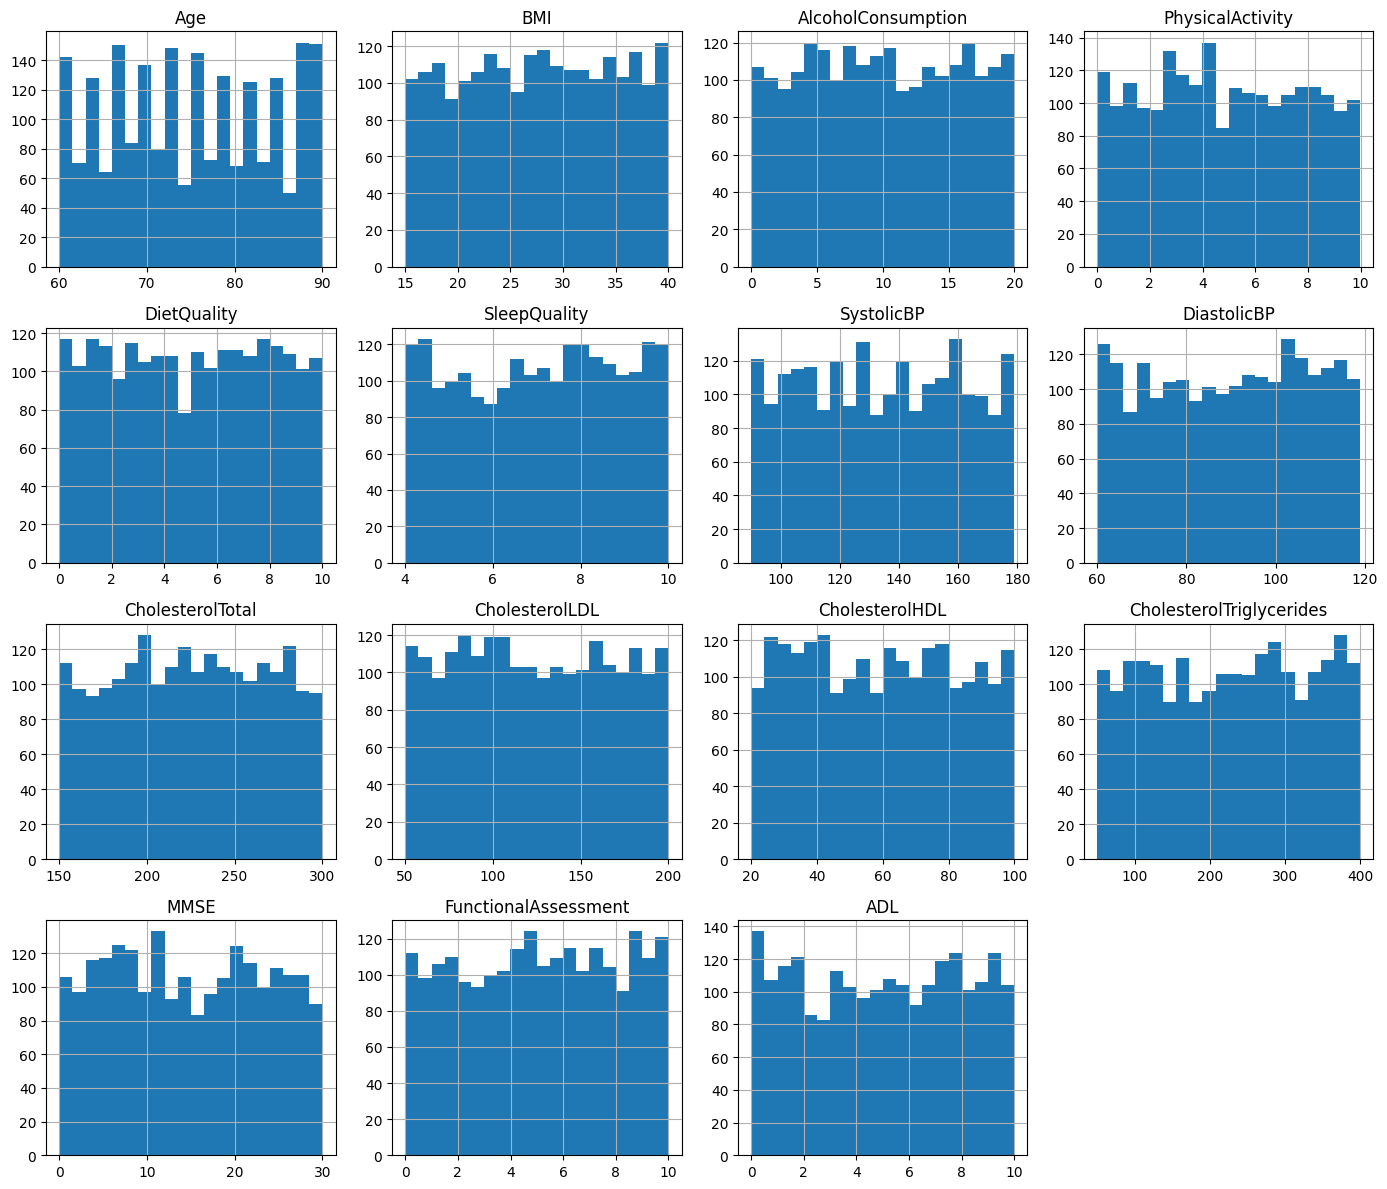

In [ ]:
numerical_attributes = [
    'Age',
    'BMI',
    'AlcoholConsumption',
    'PhysicalActivity',
    'DietQuality',
    'SleepQuality',
    'SystolicBP',
    'DiastolicBP',
    'CholesterolTotal',
    'CholesterolLDL',
    'CholesterolHDL',
    'CholesterolTriglycerides',
    'MMSE',
    'FunctionalAssessment',
    'ADL'
]

df[numerical_attributes].hist(figsize=(14, 12), bins=20)
plt.tight_layout()
plt.show()

The histograms show the distributions of the 15 numerical attributes. All of them are approximately uniform across their ranges, with no strong skewness, so no variable transformation is needed. However, the attributes are measured on very different scales (for example, Age ranges from 60 to 90, while CholesterolTriglycerides ranges from 50 to 400), so Min-Max normalization was applied in Section 4.2 to make them comparable. The BMI histogram also shows values spread across all clinical weight ranges (15 to 40), which supports discretizing it into WHO categories (Section 4.3). The comb-like pattern in the Age histogram is a binning effect: Age is a whole number with 31 possible values spread over 20 bins, so some bins hold two ages and others hold one.


### 3.2 Categorical Attribute Distributions

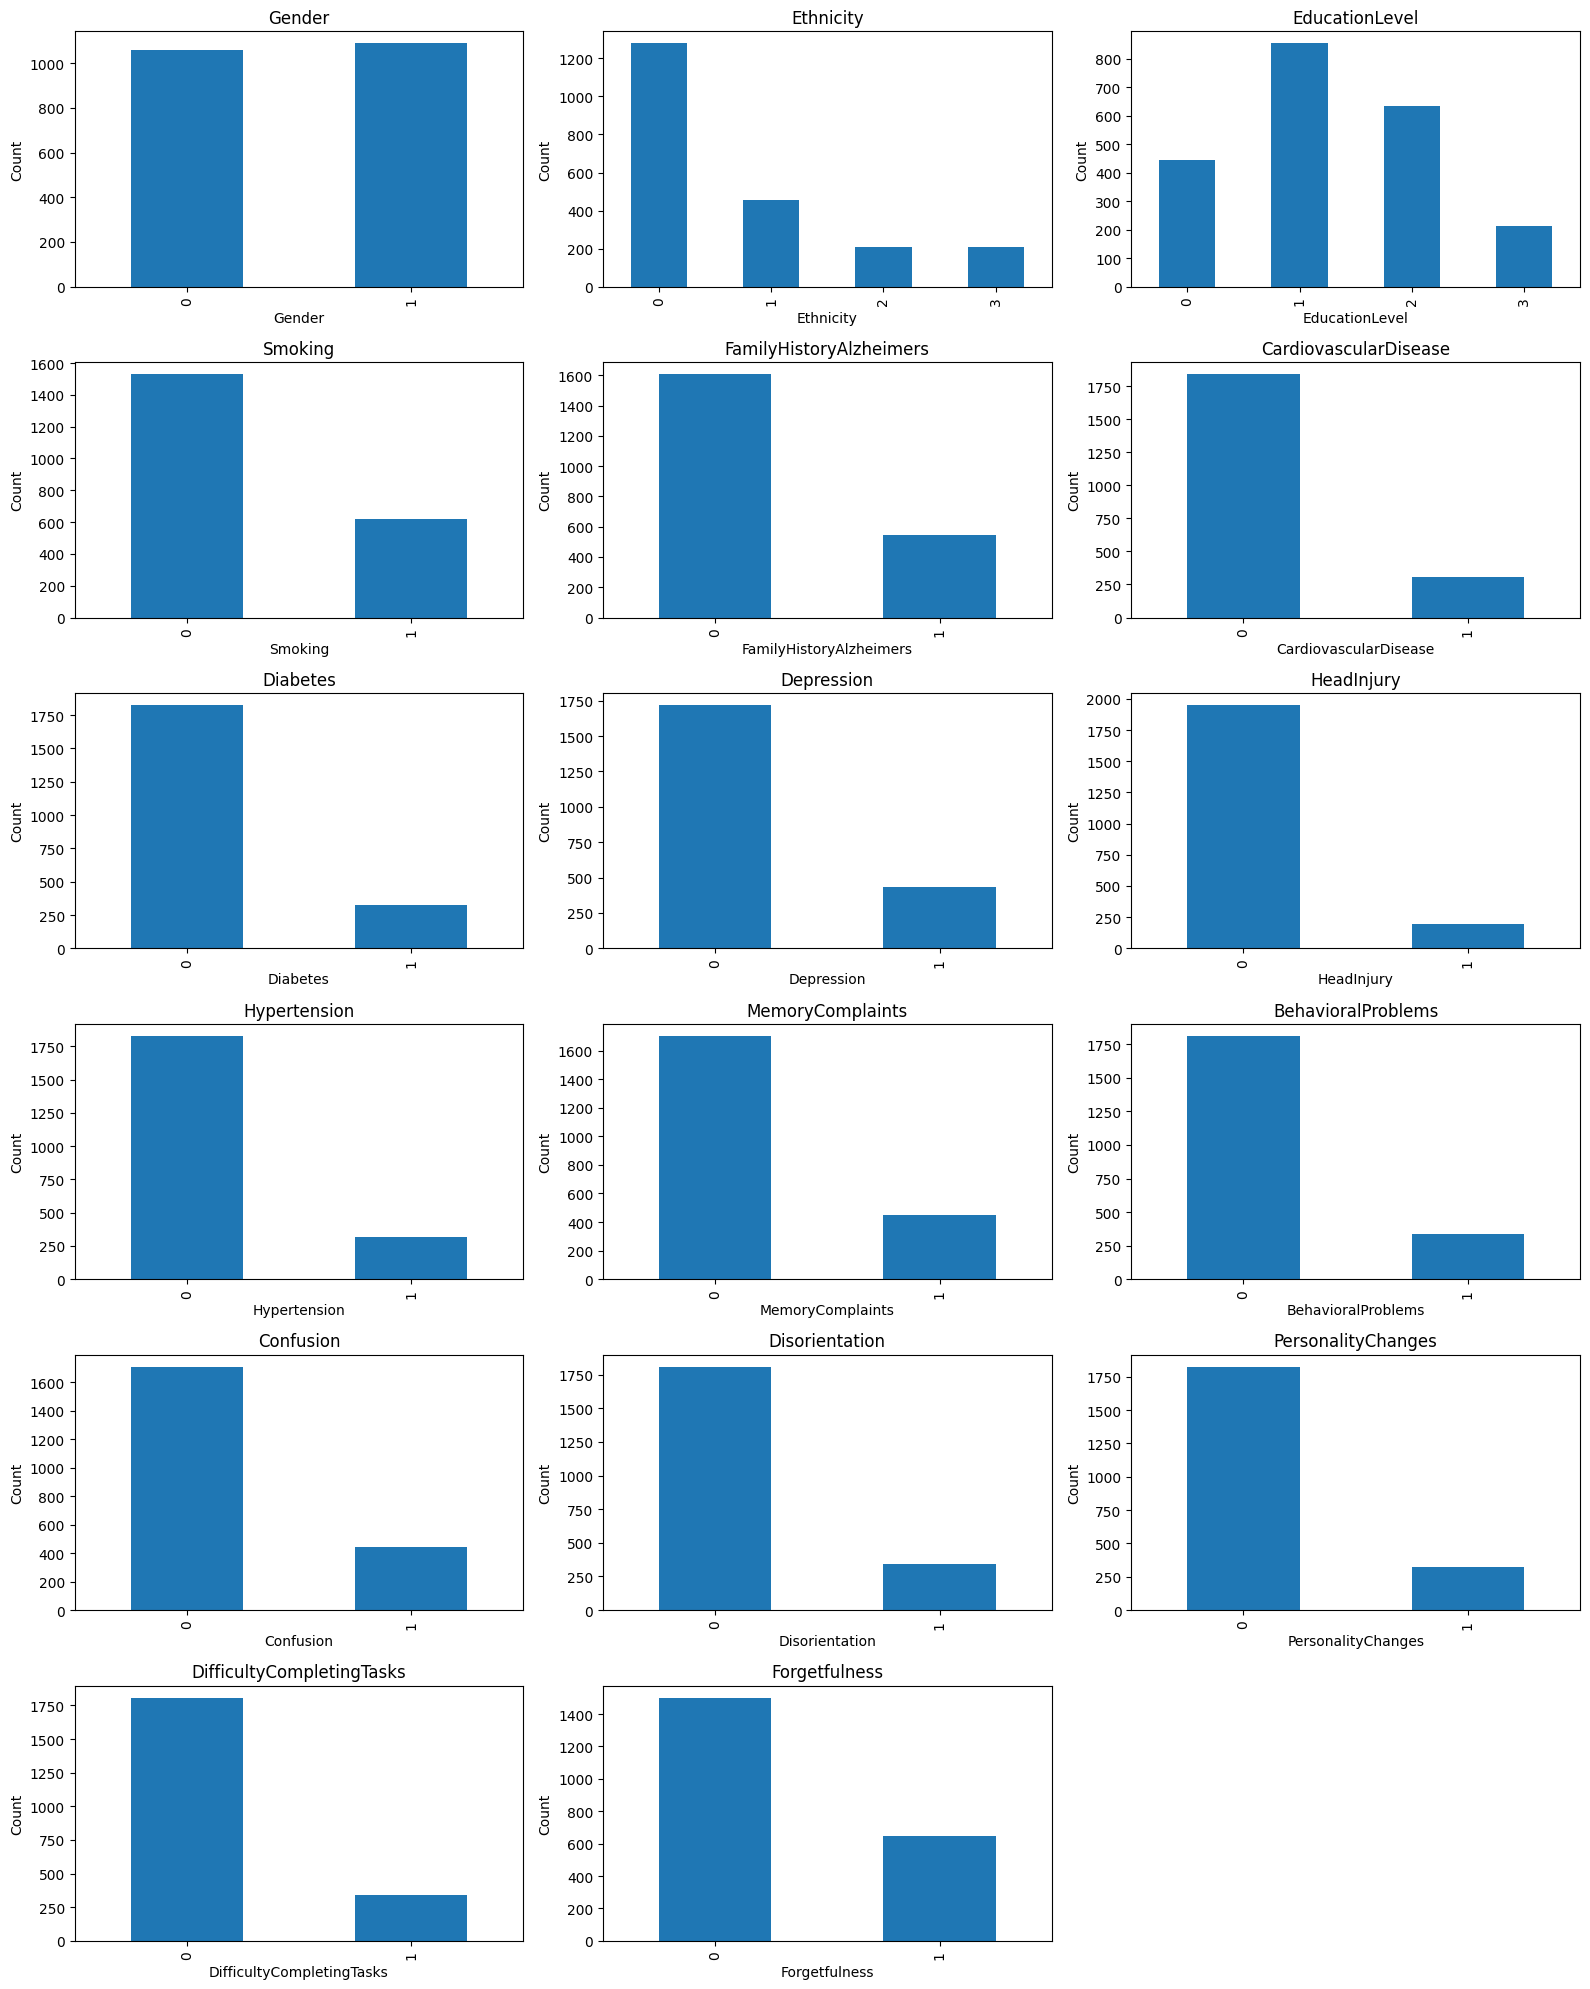

In [ ]:
categorical_attributes = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryAlzheimers',
    'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

fig, axes = plt.subplots(6, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_attributes):
    df[col].value_counts().sort_index().plot(
        kind='bar',
        ax=axes[i],
        title=col,
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(len(categorical_attributes), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

The bar plots show the frequency distribution of the 17 categorical attributes. Gender is nearly balanced (1,088 vs. 1,061). Ethnicity is dominated by group 0 (1,278 patients, 59.5%), and EducationLevel is most often level 1 (854 patients, 39.7%). The binary medical history and symptom attributes are all skewed toward 0 (absent): for example, only 199 patients (9.3%) have a head injury and 310 (14.4%) have cardiovascular disease, while Forgetfulness is the most common symptom (648 patients, 30.2%). These imbalances reflect realistic prevalence rates and are not errors, so no correction was applied. All categorical attributes are already numerically encoded (binary 0/1 or integer category codes), so no encoding step is needed.


### 3.3 Class Label Distribution

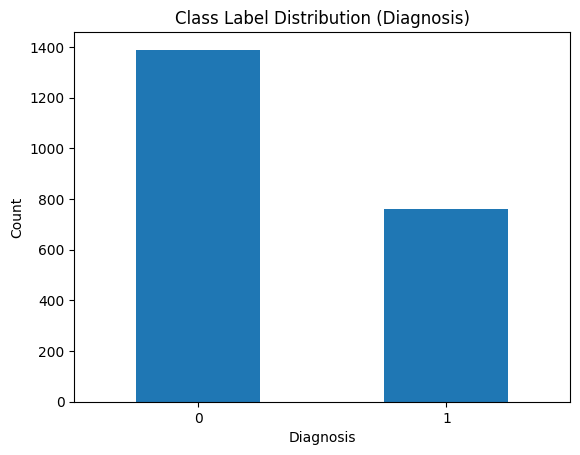

Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [ ]:
diagnosis_counts = df['Diagnosis'].value_counts().sort_index()

diagnosis_counts.plot(kind='bar')

plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.title('Class Label Distribution (Diagnosis)')
plt.xticks(rotation=0)
plt.show()

print(diagnosis_counts)


**Interpretation:** The class label is binary: 1,389 patients (64.6%) are not diagnosed with Alzheimer's (0) and 760 (35.4%) are diagnosed (1). This is a moderate class imbalance. It does not require resampling in preprocessing, but in Phase 3 we will use a stratified train/test split so both classes keep the same proportions in each partition.


## 4. Relationships and Preprocessing


### 4.1 Relationship Analysis


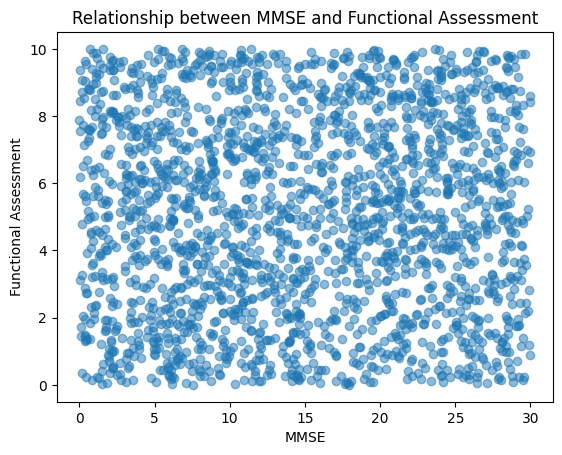

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['MMSE'], df['FunctionalAssessment'], alpha=0.5)

plt.xlabel('MMSE')
plt.ylabel('Functional Assessment')
plt.title('Relationship between MMSE and Functional Assessment')

plt.show()

**Interpretation:**
The scatter plot shows no clear linear relationship between MMSE and Functional Assessment. The points are widely scattered, indicating that changes in MMSE are not strongly associated with consistent changes in Functional Assessment. This result did not indicate a need for transformation based on the relationship between these two attributes.

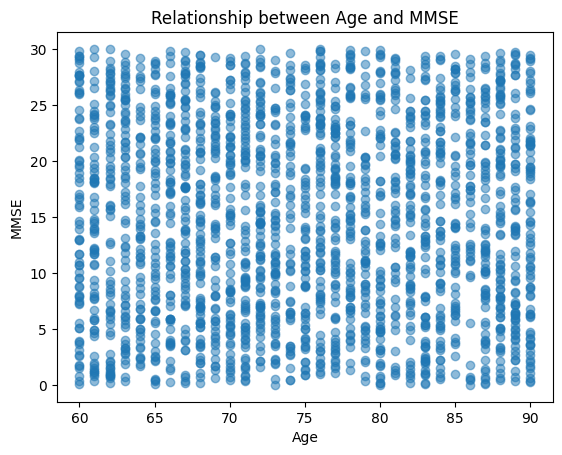

In [ ]:
plt.scatter(df['Age'], df['MMSE'], alpha=0.5)

plt.xlabel('Age')
plt.ylabel('MMSE')
plt.title('Relationship between Age and MMSE')

plt.show()

**Interpretation:**
The scatter plot shows no clear linear relationship between Age and MMSE. MMSE scores are widely distributed across all age groups, indicating that age alone does not show a strong association with MMSE scores in this dataset. This result also did not indicate a need for transformation based on the relationship between these two attributes.

### 4.2 Preprocessing

**Preprocessing Decision:** The analysis showed no missing values, no outliers, and no strong skewness, so missing-value treatment, outlier treatment, and transformation were not required. Three preprocessing techniques were applied: (1) Min-Max normalization of the continuous attributes because they are measured on different scales; (2) discretization of BMI into four clinical categories (Underweight, Normal, Overweight, and Obese); and (3) feature selection using Mutual Information with the class label (Section 5.1). The original raw dataset was kept unchanged.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

numerical_columns = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE',
    'FunctionalAssessment', 'ADL'
]

df_normalized = df.copy()

scaler = MinMaxScaler()
df_normalized[numerical_columns] = scaler.fit_transform(
    df_normalized[numerical_columns]
)

In [ ]:
df_normalized[numerical_columns].agg(['min', 'max'])

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,ADL
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Normalization Result:**
Min-Max normalization was successfully applied to the 15 continuous numerical attributes. After normalization, the minimum value of each attribute is 0 and the maximum value is 1. The categorical/binary attributes and the class label (Diagnosis) were not normalized.



### 4.3 Discretization

**Discretization Decision:** BMI is a continuous numerical attribute. It was discretized into four categories: Underweight (<18.5), Normal (18.5–24.9), Overweight (25–29.9), and Obese (≥30). This converts the continuous BMI values into clinically meaningful groups while keeping the original raw dataset unchanged.

In [ ]:
bmi_bins = [0, 18.5, 25, 30, float('inf')]
bmi_labels = [0, 1, 2, 3]

df_normalized['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=bmi_bins,
    labels=bmi_labels,
    right=False
).astype(int)

# Remove the original continuous BMI attribute
df_normalized = df_normalized.drop(columns=['BMI'])

df_normalized['BMI_Category'].value_counts().sort_index()

,count
BMI_Category,
0,297
1,544
2,437
3,871


**Discretization Result:** BMI was successfully discretized into four categories: Underweight = 297, Normal = 544, Overweight = 437, and Obese = 871 patients. The continuous BMI attribute was replaced by the new BMI_Category attribute to represent clinically meaningful BMI groups.

## 5. Feature Selection & Final Processed Dataset

### 5.1 Feature Selection

Feature selection was performed in two steps. First, PatientID and DoctorInCharge were removed because they are identifiers with no analytical value. Second, mutual information (MI) was calculated between each remaining attribute and Diagnosis to measure how much information each attribute provides about the class. Attributes with near-zero MI were removed, because irrelevant attributes add noise and especially harm K-means clustering, where every attribute contributes to the distance calculation.

FunctionalAssessment         9.545358e-02
ADL                          7.656440e-02
MMSE                         6.627780e-02
MemoryComplaints             4.525652e-02
BehavioralProblems           2.404733e-02
AlcoholConsumption           1.778024e-02
CholesterolHDL               1.734934e-02
SleepQuality                 9.691288e-03
PhysicalActivity             7.946601e-03
Age                          6.752936e-03
SystolicBP                   6.447558e-03
Ethnicity                    1.465159e-03
BMI_Category                 1.182164e-03
EducationLevel               1.034077e-03
Hypertension                 6.074235e-04
FamilyHistoryAlzheimers      5.456632e-04
Diabetes                     5.031651e-04
CardiovascularDisease        4.899146e-04
CholesterolTotal             3.381637e-04
Disorientation               3.068256e-04
HeadInjury                   2.322640e-04
Gender                       2.199678e-04
PersonalityChanges           2.145972e-04
Confusion                    1.851

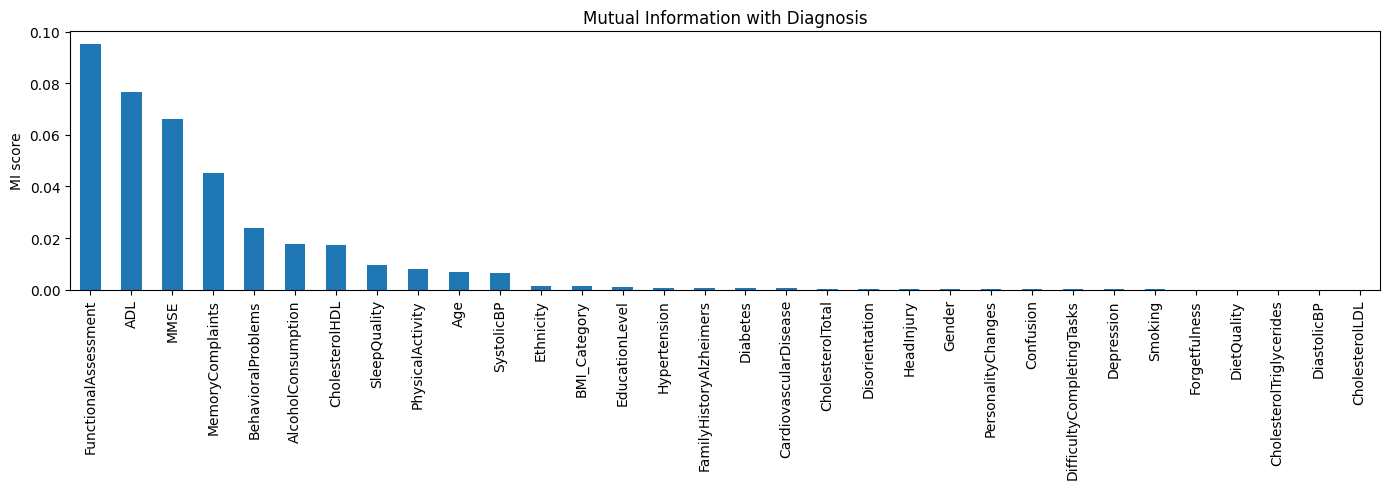

In [ ]:
from sklearn.feature_selection import mutual_info_classif
df_final = df_normalized.drop(columns=['PatientID', 'DoctorInCharge'])
X = df_final.drop(columns=['Diagnosis'])
y = df_final['Diagnosis']
discrete_mask = [col not in numerical_columns for col in X.columns]
mi = pd.Series(mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=42),
               index=X.columns).sort_values(ascending=False)
print(mi)
mi.plot(kind='bar', figsize=(14, 5), title='Mutual Information with Diagnosis')
plt.ylabel('MI score')
plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.01

selected = mi[mi > threshold].index.tolist()

df_final = df_final[selected + ['Diagnosis']]

print("Selected features:", selected)
print("Number of selected features:", len(selected))
print("Number of removed features:", len(mi) - len(selected))
print("Shape after feature selection:", df_final.shape)

Selected features: ['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'AlcoholConsumption', 'CholesterolHDL']
Number of selected features: 7
Number of removed features: 25
Shape after feature selection: (2149, 8)


Feature Selection Result: The MI scores show that FunctionalAssessment, ADL, MMSE, and MemoryComplaints provide the most information about Diagnosis, while most other attributes scored close to zero. Using a threshold of 0.01, 7 attributes were kept and 25 were removed. The selected features are FunctionalAssessment, ADL, MMSE, MemoryComplaints, BehavioralProblems, AlcoholConsumption, and CholesterolHDL. BMI_Category was also removed at this step because its MI score was very low (≈0.001). This agrees with Dubey et al., who used the K-Best method (Chi-square and ANOVA F-value) and selected FunctionalAssessment, MMSE, ADL, MemoryComplaints, and BehavioralProblems as the top 5 features; all five are included in our selection. Our selection also kept AlcoholConsumption and CholesterolHDL, which passed the threshold with lower MI scores. The final dataset has 8 attributes, including the class label.

### 5.2 Final Preprocessed Dataset

In [ ]:
# Display the first five rows of the final preprocessed dataset
df_final.head()

,FunctionalAssessment,ADL,MMSE,MemoryComplaints,BehavioralProblems,AlcoholConsumption,CholesterolHDL,Diagnosis
0,0.652102,0.172486,0.715606,0,0,0.665183,0.171039,0
1,0.712108,0.259154,0.687251,0,0,0.227170,0.738026,0
2,0.589697,0.711936,0.245145,0,0,0.978276,0.622290,0
3,0.896823,0.648094,0.466410,0,1,0.610751,0.605851,0
4,0.604699,0.001341,0.450619,0,0,0.923204,0.461019,0


### 5.3 Raw vs. Preprocessed Dataset Comparison

In [ ]:
# Compare the raw dataset with the final preprocessed dataset
print("Raw dataset shape:", df.shape)
print("Final preprocessed dataset shape:", df_final.shape)

print("\nRaw dataset columns:")
print(df.columns.tolist())

print("\nFinal preprocessed dataset columns:")
print(df_final.columns.tolist())

Raw dataset shape: (2149, 35)
Final preprocessed dataset shape: (2149, 8)

Raw dataset columns:
['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']

Final preprocessed dataset columns:
['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'AlcoholConsumption', 'CholesterolHDL', 'Diagnosis']


In [ ]:
# Snapshot of the raw dataset (unchanged)
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
# Compare sample values before and after preprocessing
comparison = pd.DataFrame({
    'Raw Age': df['Age'].head(),
    'Normalized Age': df_normalized['Age'].head(),
    'Raw BMI': df['BMI'].head(),
    'BMI Category': df_normalized['BMI_Category'].head()
})

comparison

,Raw Age,Normalized Age,Raw BMI,BMI Category
0,73,0.433333,22.927749,1
1,89,0.966667,26.827681,2
2,73,0.433333,17.795882,0
3,74,0.466667,33.800817,3
4,89,0.966667,20.716974,1


Comparison Result: The raw and preprocessed datasets contain the same 2,149 records, so no patients were removed. The number of attributes was reduced from 35 to 8 by removing the identifier columns and the low-information attributes found by feature selection. The continuous attributes were scaled to [0, 1] with Min-Max normalization, and the binary attributes and the Diagnosis label kept their original coded values. BMI was discretized into a 4-level clinical category (Section 4.3), but this category was later removed by feature selection due to its low MI score.

### 5.4 Save and Verify the Final Dataset

In [ ]:
# Save the final preprocessed dataset
df_final.to_csv('Preprocessed_dataset.csv', index=False)

print("Preprocessed_dataset.csv saved successfully.")

Preprocessed_dataset.csv saved successfully.


In [ ]:
# Verify the saved preprocessed dataset
df_check = pd.read_csv('Preprocessed_dataset.csv')

print("Saved dataset shape:", df_check.shape)
df_check.head()

Saved dataset shape: (2149, 8)


,FunctionalAssessment,ADL,MMSE,MemoryComplaints,BehavioralProblems,AlcoholConsumption,CholesterolHDL,Diagnosis
0,0.652102,0.172486,0.715606,0,0,0.665183,0.171039,0
1,0.712108,0.259154,0.687251,0,0,0.227170,0.738026,0
2,0.589697,0.711936,0.245145,0,0,0.978276,0.622290,0
3,0.896823,0.648094,0.466410,0,1,0.610751,0.605851,0
4,0.604699,0.001341,0.450619,0,0,0.923204,0.461019,0
